# CMB Acoustic Peak Heights and the Cold Dark Matter Density

Narrative notebook, not a live pipeline. Every array plotted here comes from the
cached `.npz` files in `data/`, written by `scripts/01_baseline.py` and
`scripts/02_sweep.py`. No CLASS computation happens in this notebook, so it
renders and reruns in seconds without a compiled Boltzmann code.

**Scope, stated plainly:** this reproduces a textbook result established in the
1990s-2000s (Hu & Sugiyama, Hu & Dodelson) and confirmed by WMAP and Planck. It
is not novel research, and the Planck overlay is a visual comparison, not a
likelihood analysis -- nothing here measures &Omega;<sub>c</sub>. Full narrative:
`README.md`. Full technical reference: `RESEARCH_BLUEPRINT.md`.

In [1]:
%matplotlib inline

import numpy as np

from cmbpeaks.config import DATA_DIR
from cmbpeaks.peaks import find_acoustic_peaks, peak_ratios
from cmbpeaks.planck import load_planck_tt
from cmbpeaks.plotting import (
    plot_baseline_overlay,
    plot_paired_sweeps,
    plot_sweep,
    report_benchmarks,
)
from cmbpeaks.sweep import SweepResult

## 1. Baseline vs Planck

The Planck 2018 base-&Lambda;CDM best fit (lensed TT spectrum), overlaid on the
binned Planck band powers. This is the reproduction check everything else
builds on: if the peak positions and heights don't match Table 5 of Planck
2018 I, nothing downstream is trustworthy.


  peak   ell (CLASS)   ell (Planck)    Dl (CLASS)   Dl (Planck)
    1         220.3         220.6          5730          5733
    2         536.1         538.1          2593          2586
    3         812.9         809.8          2540          2518

D1/D2 = 2.210
D3/D2 = 0.980


wrote /mnt/c/Users/aryan/OneDrive/Desktop/CMB dark matter sensitivity study/figures/01_baseline_overlay.png


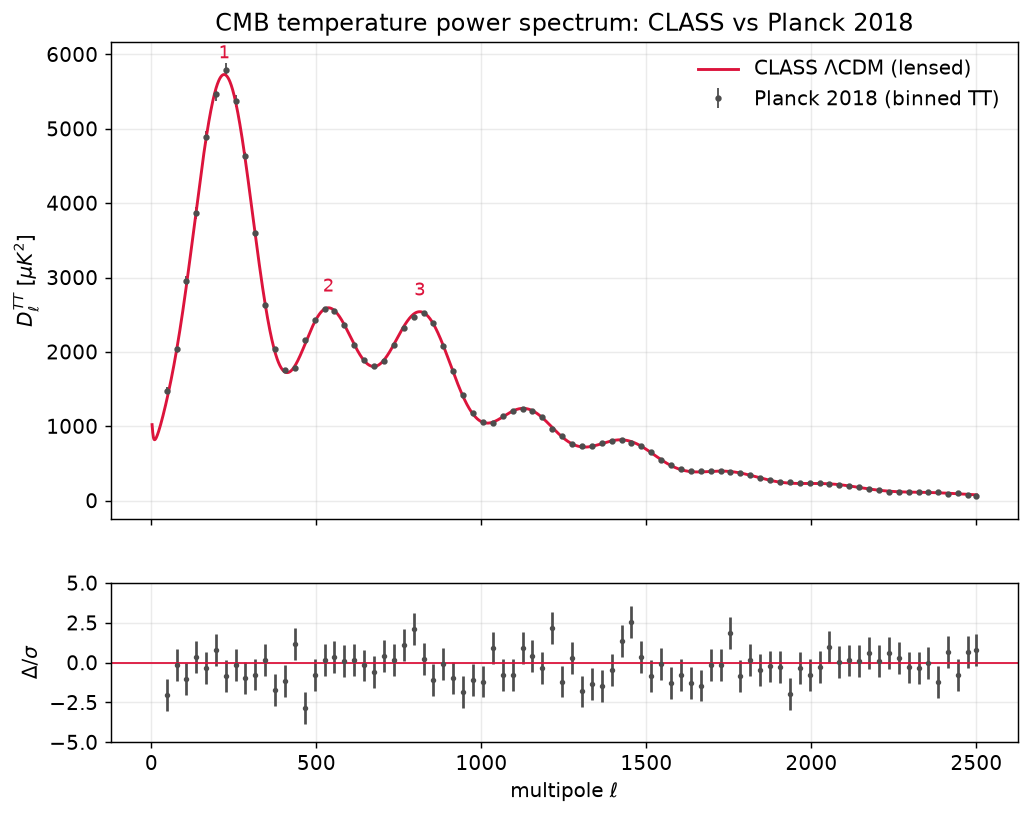

In [2]:
baseline = np.load(DATA_DIR / "baseline_Dl.npz")
ell, dl = baseline["ell"], baseline["dl"]

planck = load_planck_tt()
peaks = find_acoustic_peaks(ell, dl, n_peaks=3)
ok = report_benchmarks(peaks)

ratios = peak_ratios(peaks)
print(f"\nD1/D2 = {ratios['D1_over_D2']:.3f}")
print(f"D3/D2 = {ratios['D3_over_D2']:.3f}")

plot_baseline_overlay(ell, dl, planck, peaks=peaks);

## 2. The `omega_cdm` sweep

Sixteen-point grid, &omega;<sub>cdm</sub> &isin; [0.05, 0.20], run twice --
once holding `h` fixed and once holding the angular acoustic scale
`100*theta_s` fixed with CLASS solving for `h` by shooting. See `README.md`'s
Methodology section for why both are needed and what the D1/D2 sign reversal
means.

wrote /mnt/c/Users/aryan/OneDrive/Desktop/CMB dark matter sensitivity study/figures/02_sweep_ratio_fixed_h.png


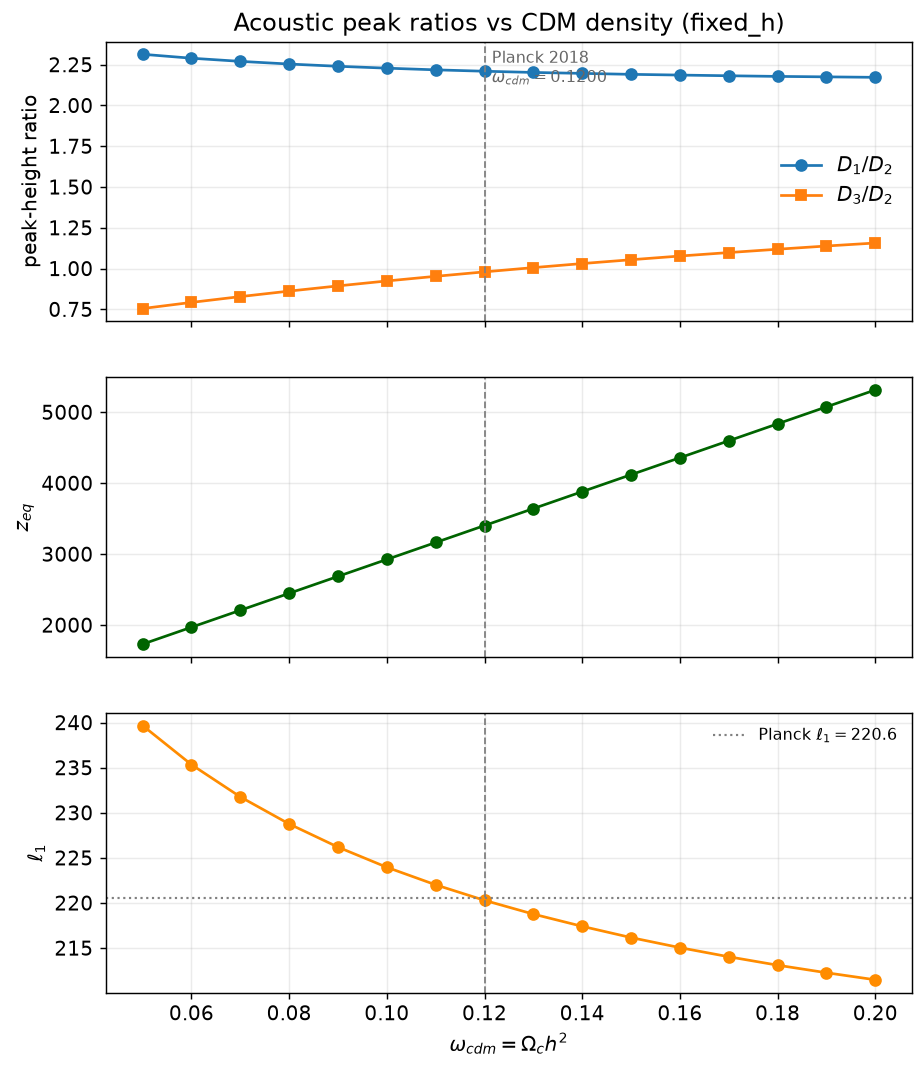

In [3]:
res_h = SweepResult.load(DATA_DIR / "sweep_fixed_h.npz")
res_theta = SweepResult.load(DATA_DIR / "sweep_fixed_theta_s.npz")

plot_sweep(res_h, name="02_sweep_ratio_fixed_h.png");

wrote /mnt/c/Users/aryan/OneDrive/Desktop/CMB dark matter sensitivity study/figures/02_sweep_ratio_fixed_theta_s.png


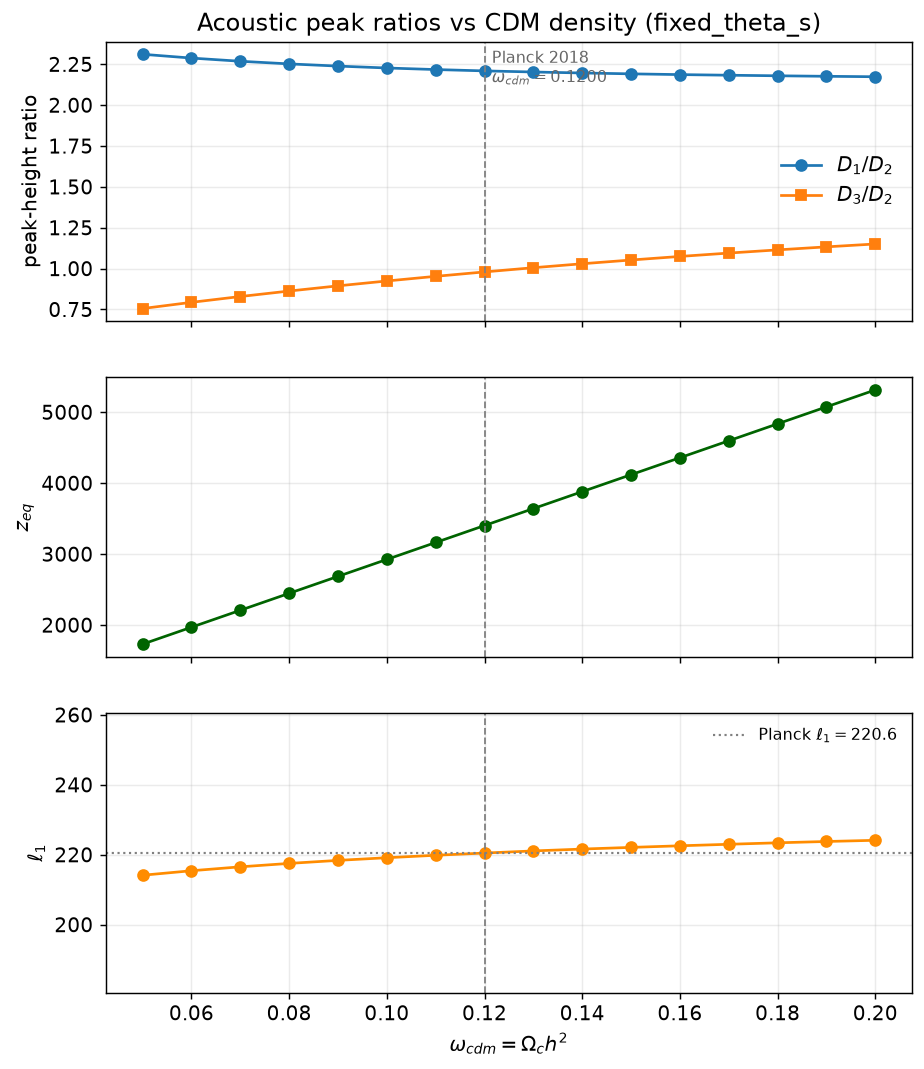

In [4]:
plot_sweep(res_theta, name="02_sweep_ratio_fixed_theta_s.png");

## 3. Paired comparison: fixed h vs fixed theta_s

Same spectra, side by side. The left panel shows peak positions sliding along
with amplitudes as `omega_cdm` changes; the right panel holds the acoustic
scale fixed so only the amplitude effect -- the dark matter physics -- remains.

wrote /mnt/c/Users/aryan/OneDrive/Desktop/CMB dark matter sensitivity study/figures/03_fixed_h_vs_fixed_theta.png
first-peak spread, fixed h:     28.2 in ell
first-peak spread, fixed theta: 10.0 in ell


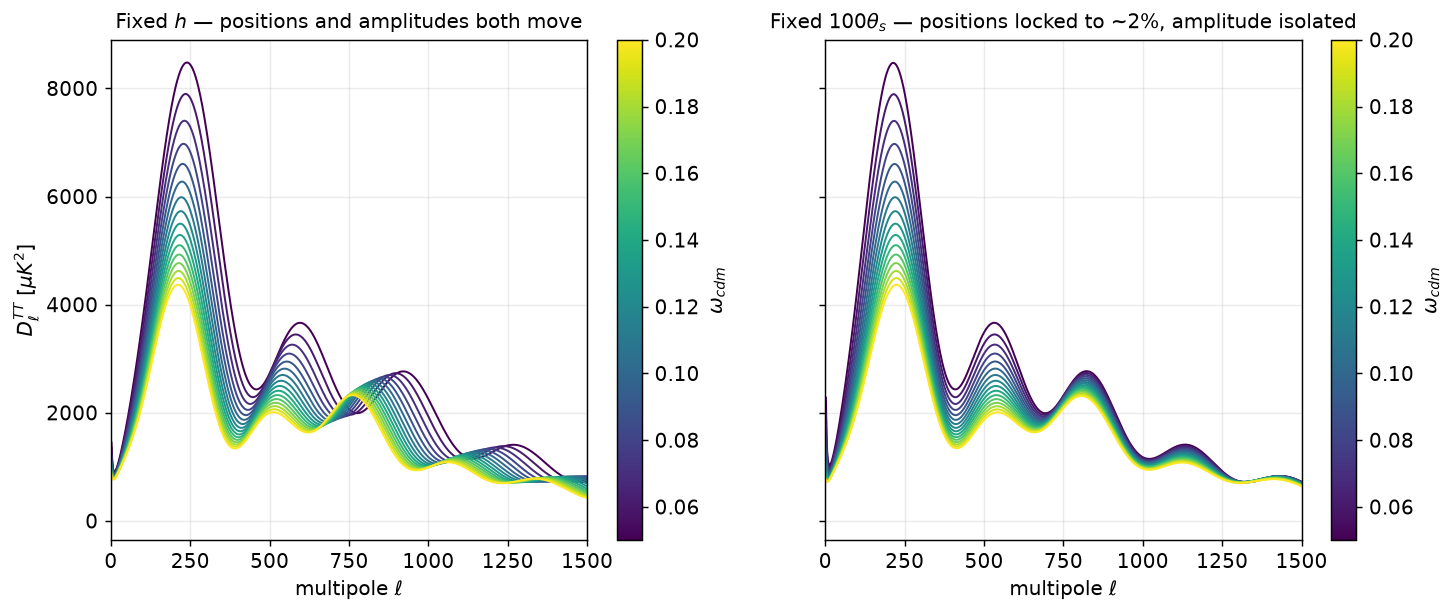

In [5]:
plot_paired_sweeps(res_h, res_theta);

ell1_h = res_h.peak_ells[:, 0]
ell1_t = res_theta.peak_ells[:, 0]
print(f"first-peak spread, fixed h:     {ell1_h.max() - ell1_h.min():.1f} in ell")
print(f"first-peak spread, fixed theta: {ell1_t.max() - ell1_t.min():.1f} in ell")

---

Full write-up -- including the quantitative check on the shooting solver and
the open question of why D1/D2 falls instead of rising with
&omega;<sub>cdm</sub> -- is in `README.md`. Build history and benchmarks are
in `PLAN.md`.